In [2]:
import logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as patches

import sys
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
sys.path.insert(1, str(E9path))
import E9_fn.E9_constants as E9c
import E9_fn.thermodynamics as thmdy
from E9_fn import util
from E9_fn.tight_binding import E9tb
from projects.flat_band_cooling import helper_fns as hpfn

logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

c:\Users\ken92\Documents\Studies\E5\simulation\E9_simulations\.venv\Lib\site-packages\gftool\precision.py:16: UserWarning: No quad precision datatypes available!
Some functions might be less accurate.
  warnings.warn("No quad precision datatypes available!\n"


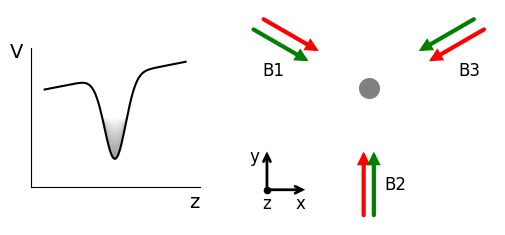

In [48]:
fig, (ax_trap, ax_lat) = plt.subplots(1, 2, figsize = (6, 3), width_ratios = [2, 3])

_arrow_dir = [E9c.k1k, E9c.k2k, E9c.k3k]
arrow_tips = [-0.25 * v for v in _arrow_dir]
arrow_ends = [-0.5 * v for v in _arrow_dir]
red_delta = [np.array([-0.02, -0.02]), np.array([0.02, 0]), np.array([-0.02, 0.02])]
green_delta = [np.array([0.02, 0.02]), np.array([-0.02, 0]), np.array([0.02, -0.02])]

pos = ax_trap.get_position()
new_y0 = pos.y0 + pos.height * 0.20
new_height = pos.height * 0.60
ax_trap.set_position([pos.x0, new_y0, pos.width, new_height])

# for ax in [ax_lat]:
for ax in (ax_trap, ax_lat):
    ax.set_xticks([])
    ax.set_yticks([])
ax_trap.spines[['top', 'right']].set_visible(False)
ax_lat.spines[:].set_visible(False)

# trapping potential
xr = np.linspace(-1, 1, 201)
wODT = 0.15
VODT = -0.3
ag = 0.05
E_F = -0.15
Vx = ag * xr + VODT *util.Gaussian_1D(xr, wODT, normalization = "max1")
ax_trap.plot(xr, Vx, color = "black")
ax_trap.set_xlim(-1.2, 1.2)
ax_trap.set_ylim(-0.4, 0.1)
util.fill_between_ygradient(ax_trap, xr, Vx, E_F * np.ones_like(Vx),
                            color1 = np.array([0.5, 0.5, 0.5, 1]), color2 = np.array([0.5, 0.5, 0.5, 0]),
                            fill_params = {"where": Vx < E_F})
ax_trap.set_xlabel("z", loc = "right", size = 14)
ax_trap.set_ylabel("V", y = 0.9, size = 14, rotation = "horizontal", labelpad = 10)

# Lattice setup
ax_lat.set_aspect(1)
for cl, delta_list in zip(["red", "green"], [green_delta, red_delta]):
    for p1, p2, delta in zip(arrow_ends, arrow_tips, delta_list):
        arrow = FancyArrowPatch(
            p1 + delta, p2 + delta,
            edgecolor = cl,
            facecolor = cl,
            linewidth = 3,
            arrowstyle = '-|>,head_width=0.025,head_length=0.05',
            mutation_scale = 100,
            joinstyle = "miter",
            shrinkA = 0,
            shrinkB = 0
        )
        ax_lat.add_patch(arrow)

ax_lat.scatter(0, 0, s = 200, color = "gray")
ax_lat.text(*arrow_ends[0] + np.array([0.015, -0.2]), "B1", color = "black", fontsize = 12)
ax_lat.text(*arrow_ends[1] + np.array([0.06, 0.1]), "B2", color = "black", fontsize = 12)
ax_lat.text(*arrow_ends[2] + np.array([-0.08, -0.2]), "B3", color = "black", fontsize = 12)

# orientation
coor_pos = np.array([-0.4, -0.4])
x_axis_tip = np.array([0.15, 0]) + coor_pos
y_axis_tip = np.array([0, 0.15]) + coor_pos
for p1 in (x_axis_tip, y_axis_tip):
    arrow = FancyArrowPatch(
        coor_pos, p1,
        edgecolor = "black",
        facecolor = "black",
        linewidth = 2,
        arrowstyle = '->,head_width=0.025,head_length=0.05',
        mutation_scale = 100,
        joinstyle = "miter",
        shrinkA = 0,
        shrinkB = 0
    )
    ax_lat.add_patch(arrow)
ax_lat.text(*x_axis_tip + np.array([-0.02, -0.02]), "x", fontsize = 12, ha = "center", va = "top")
ax_lat.text(*y_axis_tip + np.array([-0.03, -0.02]), "y", fontsize = 12, ha = "right", va = "center")
ax_lat.scatter(*coor_pos, s = 20, color = "black")
ax_lat.text(*coor_pos + np.array([0., -0.02]), "z", fontsize = 12, ha = "center", va = "top")

thesis_fig_path_app = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\introduction")
file_name = "exp_intro.pdf"
file_full_path = Path(thesis_fig_path_app, file_name)
fig.savefig(file_full_path, facecolor = "none", dpi = 300, bbox_inches='tight')